This notebook reproduces the SQL cohort analysis using Pandas for efficiency comparison.

In [9]:
from sqlalchemy import create_engine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set();

In [2]:
engine = create_engine('mssql+pyodbc://@LAPTOP/AdventureWorksDW2025?driver=SQL+Server&Trusted_Connection=yes')

query = """
SELECT 
    CustomerKey, 
    DueDate, 
    SalesAmount, 
    SalesOrderNumber, 
    OrderQuantity, 
    EnglishProductName 
FROM dbo.FactInternetSales f
JOIN dbo.DimProduct p ON f.ProductKey = p.ProductKey
WHERE YEAR(DueDate) > 2011
"""

df = pd.read_sql_query(query, engine)

In [3]:
df.columns = ['cust_key', 'date', 'sales_amount', 'order_count', 'quantity', 'product_n']

In [4]:
df

,cust_key,date,sales_amount,order_count,quantity,product_n
0,11427,2012-01-01,3399.99,SO46537,1,"Mountain-100 Silver, 38"
1,12774,2012-01-01,3578.27,SO46538,1,"Road-150 Red, 62"
2,12200,2012-01-01,3578.27,SO46539,1,"Road-150 Red, 56"
3,20822,2012-01-01,3578.27,SO46540,1,"Road-150 Red, 56"
4,20617,2012-01-01,3578.27,SO46541,1,"Road-150 Red, 62"
...,...,...,...,...,...,...
58254,15868,2014-02-09,21.98,SO75122,1,Fender Set - Mountain
58255,15868,2014-02-09,8.99,SO75122,1,AWC Logo Cap
58256,18759,2014-02-09,21.98,SO75123,1,Fender Set - Mountain
58257,18759,2014-02-09,159.00,SO75123,1,All-Purpose Bike Stand


In [5]:
df['order_month'] = df['date'].dt.to_period('M')
df['first_purch'] = df.groupby('cust_key')['order_month'].transform('min')
df['cohort_index'] = (df['order_month'] - df['first_purch']).apply(lambda x: x.n)
df

,cust_key,date,sales_amount,order_count,quantity,product_n,order_month,first_purch,cohort_index
0,11427,2012-01-01,3399.99,SO46537,1,"Mountain-100 Silver, 38",2012-01,2012-01,0
1,12774,2012-01-01,3578.27,SO46538,1,"Road-150 Red, 62",2012-01,2012-01,0
2,12200,2012-01-01,3578.27,SO46539,1,"Road-150 Red, 56",2012-01,2012-01,0
3,20822,2012-01-01,3578.27,SO46540,1,"Road-150 Red, 56",2012-01,2012-01,0
4,20617,2012-01-01,3578.27,SO46541,1,"Road-150 Red, 62",2012-01,2012-01,0
...,...,...,...,...,...,...,...,...,...
58254,15868,2014-02-09,21.98,SO75122,1,Fender Set - Mountain,2014-02,2013-05,9
58255,15868,2014-02-09,8.99,SO75122,1,AWC Logo Cap,2014-02,2013-05,9
58256,18759,2014-02-09,21.98,SO75123,1,Fender Set - Mountain,2014-02,2013-05,9
58257,18759,2014-02-09,159.00,SO75123,1,All-Purpose Bike Stand,2014-02,2013-05,9


In [6]:
cohort_pivot = df.pivot_table(index='first_purch', 
                              columns='cohort_index', 
                              values='cust_key', 
                              aggfunc='nunique')
cohort_pivot.index = cohort_pivot.index.astype(str)  

pd.set_option('display.max_columns', None)
cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
first_purch,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01,253.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,5.0,24.0,49.0,19.0,9.0,16.0,43.0,33.0,35.0,28.0,13.0,5.0
2012-02,243.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0,9.0,15.0,26.0,32.0,4.0,21.0,31.0,28.0,32.0,30.0,7.0,NaN
2012-03,240.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,8.0,6.0,16.0,28.0,29.0,11.0,15.0,27.0,36.0,61.0,11.0,4.0,NaN,NaN
2012-04,211.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,9.0,13.0,14.0,26.0,25.0,4.0,26.0,12.0,23.0,41.0,45.0,3.0,NaN,NaN,NaN
2012-05,199.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2.0,9.0,16.0,20.0,37.0,13.0,18.0,13.0,27.0,33.0,28.0,9.0,NaN,NaN,NaN,NaN
2012-06,302.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,4.0,10.0,14.0,15.0,42.0,28.0,28.0,37.0,24.0,25.0,75.0,21.0,NaN,NaN,NaN,NaN,NaN
2012-07,265.0,NaN,NaN,NaN,NaN,NaN,13.0,12.0,10.0,11.0,20.0,33.0,36.0,38.0,25.0,14.0,23.0,47.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN
2012-08,283.0,NaN,NaN,NaN,NaN,13.0,21.0,24.0,11.0,23.0,34.0,41.0,50.0,24.0,22.0,14.0,32.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09,273.0,NaN,NaN,NaN,11.0,15.0,18.0,22.0,13.0,41.0,32.0,43.0,52.0,36.0,24.0,20.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(2)
retention

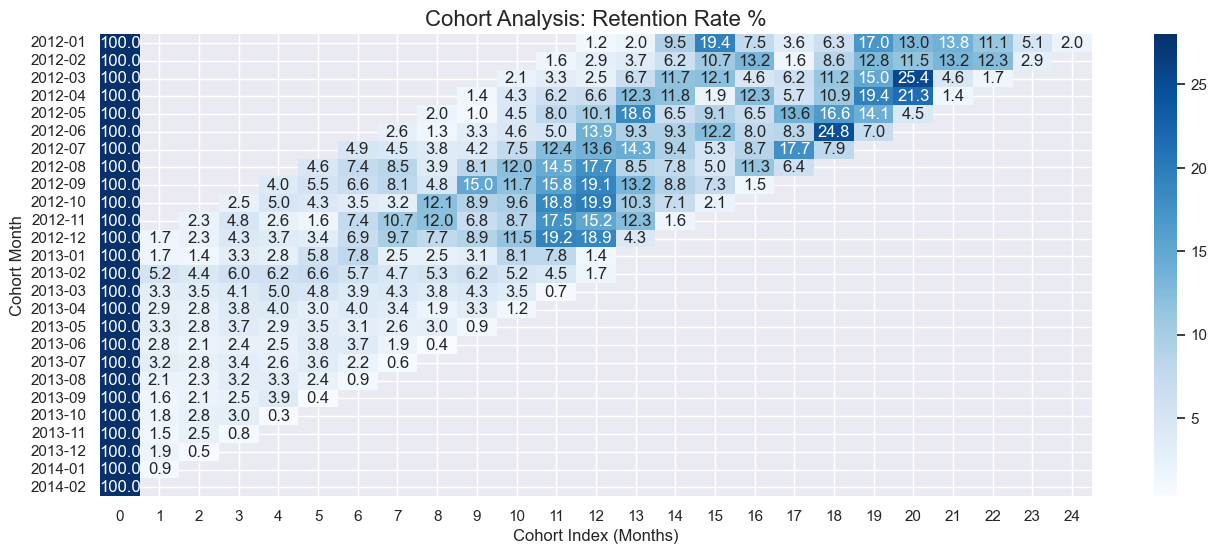

In [8]:
plt.figure(figsize=(16, 6))
sns.heatmap(retention, 
            annot=True,      
            fmt='.1f',       
            cmap='Blues',   
            vmax=28)        
plt.title('Cohort Analysis: Retention Rate %', fontsize=16)
plt.xlabel('Cohort Index (Months)', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)

plt.show()